In [11]:
print("Hello World")

Hello World


In [12]:
# ---------------------------------------------------------
# CELL 1: SETUP AND LOAD
# ---------------------------------------------------------
# Ensure our notebook automatically updates if we change our db_tools files
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import our custom database toolbox
from db_tools import loaders

db_file = 'creditdatabase.db'
table_name = 'credit card transactions'

print("Loading the complete dataset...")
df_full = loaders.load_table_to_df(db_file, table_name)
print("Load complete!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading the complete dataset...
Loading full table 'credit card transactions'...
Load complete!


In [13]:
# ---------------------------------------------------------
# CELL 2: BASIC SHAPE AND IMBALANCE
# ---------------------------------------------------------
print("--- DATASET OVERVIEW ---")
print(f"Total Rows: {df_full.shape[0]:,}")
print(f"Total Columns: {df_full.shape[1]}")
print(f"Missing Values: {df_full.isna().sum().sum()}")

print("\n--- CLASS IMBALANCE ---")
class_counts = df_full['Class'].value_counts()
class_pct = df_full['Class'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct
})
# Format the index for readability
imbalance_df.index = ['Normal (0)', 'Fraud (1)']
print(imbalance_df.round(4))

--- DATASET OVERVIEW ---
Total Rows: 284,807
Total Columns: 31
Missing Values: 0

--- CLASS IMBALANCE ---
             Count  Percentage (%)
Normal (0)  284315         99.8273
Fraud (1)      492          0.1727


In [14]:
# ---------------------------------------------------------
# CELL 8: CHECKING FOR DUPLICATES
# ---------------------------------------------------------
# Count how many rows are exact copies of another row
duplicate_count = df_full.duplicated().sum()

print(f"Total duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    print("Removing duplicates from the dataset...")
    # Keep the first instance, drop the copies
    df_full = df_full.drop_duplicates(keep='first')
    print(f"New dataset size: {df_full.shape[0]} rows.")
else:
    print("Data is clean! No duplicates.")

Total duplicate rows found: 1081
Removing duplicates from the dataset...
New dataset size: 283726 rows.


In [20]:
print("--- DATASET OVERVIEW (After Cleaning) ---")
print(f"Total Rows: {df_full.shape[0]:,}")
print(f"Total Columns: {df_full.shape[1]}")
print(f"Missing Values: {df_full.isna().sum().sum()}")

print("\n--- CLASS IMBALANCE ---")
class_counts = df_full['Class'].value_counts()
class_pct = df_full['Class'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct
})
# Format the index for readability
imbalance_df.index = ['Normal (0)', 'Fraud (1)']
print(imbalance_df.round(4))

--- DATASET OVERVIEW (After Cleaning) ---
Total Rows: 283,726
Total Columns: 32
Missing Values: 0

--- CLASS IMBALANCE ---
             Count  Percentage (%)
Normal (0)  283253         99.8333
Fraud (1)      473          0.1667


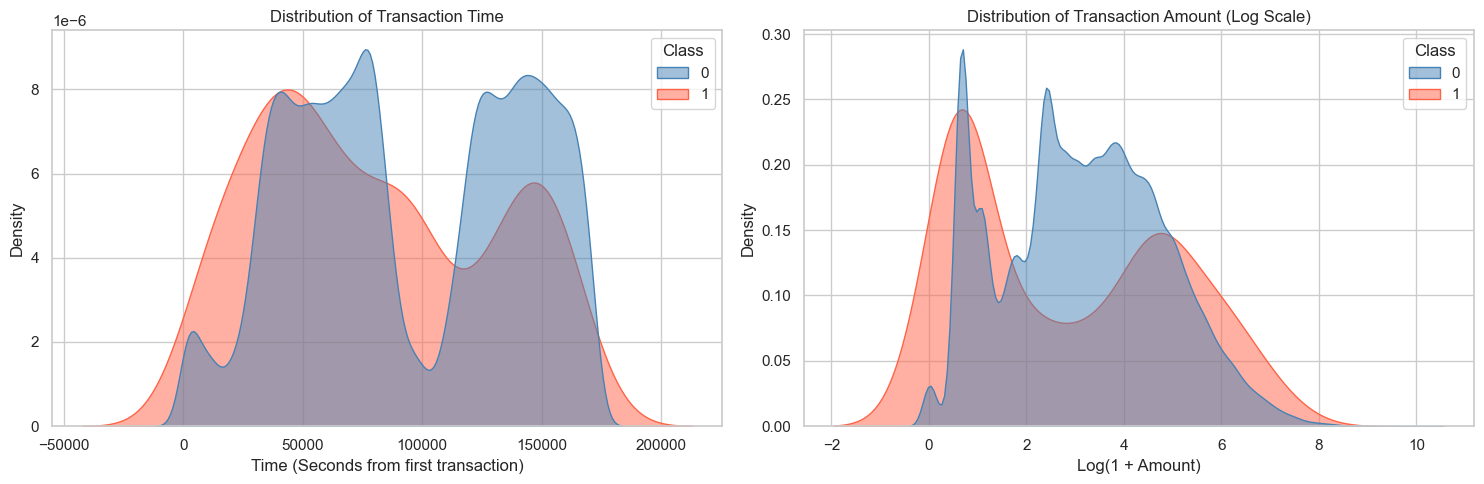

In [15]:
# ---------------------------------------------------------
# CELL 3: DISTRIBUTIONS OF TIME AND AMOUNT
# ---------------------------------------------------------
# Set a clean visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Time Distribution
# Time contains the seconds elapsed between each transaction and the first transaction in the dataset.
sns.kdeplot(data=df_full, x='Time', hue='Class', fill=True, common_norm=False, 
            palette={0: 'steelblue', 1: 'tomato'}, alpha=0.5, ax=axes[0])
axes[0].set_title('Distribution of Transaction Time')
axes[0].set_xlabel('Time (Seconds from first transaction)')

# 2. Amount Distribution (Log Scaled)
# We use np.log1p (log(1+x)) to safely handle any $0 transactions
df_full['Log_Amount'] = np.log1p(df_full['Amount'])

sns.kdeplot(data=df_full, x='Log_Amount', hue='Class', fill=True, common_norm=False, 
            palette={0: 'steelblue', 1: 'tomato'}, alpha=0.5, ax=axes[1])
axes[1].set_title('Distribution of Transaction Amount (Log Scale)')
axes[1].set_xlabel('Log(1 + Amount)')

plt.tight_layout()
plt.show()

Calculating correlations...


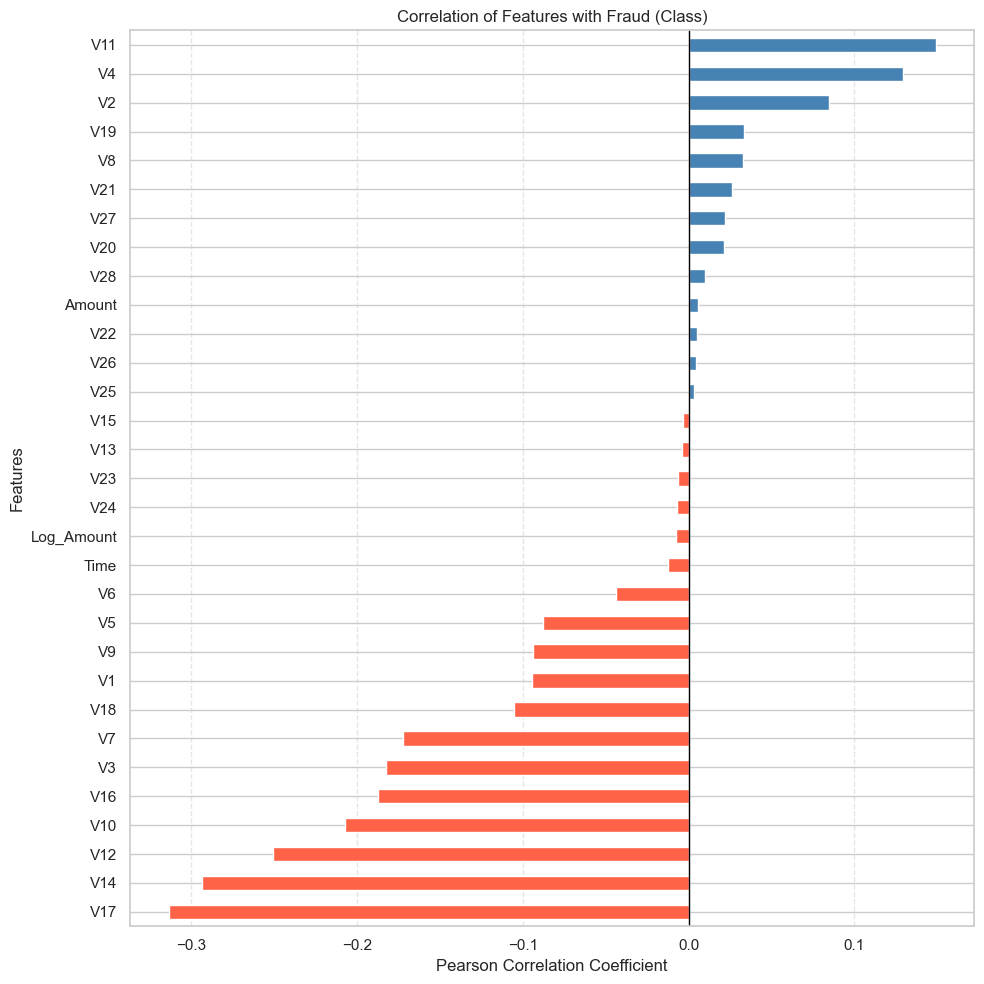

Top 3 Negative Predictors (As these drop, Fraud risk rises):
V17   -0.313498
V14   -0.293375
V12   -0.250711
Name: Class, dtype: float64

Top 3 Positive Predictors (As these rise, Fraud risk rises):
V2     0.084624
V4     0.129326
V11    0.149067
Name: Class, dtype: float64


In [16]:
# ---------------------------------------------------------
# CELL 4: FEATURE CORRELATION WITH FRAUD
# ---------------------------------------------------------
print("Calculating correlations...")

# 1. Calculate correlation of all columns against 'Class'
correlations = df_full.corr()['Class'].drop('Class')

# 2. Sort them from most negative to most positive
sorted_corrs = correlations.sort_values()

# 3. Create the Bar Graph
plt.figure(figsize=(10, 10))
# Color negative correlations red (tomato) and positive blue (steelblue)
colors = ['tomato' if x < 0 else 'steelblue' for x in sorted_corrs]

# Plot horizontal bars
sorted_corrs.plot(kind='barh', color=colors)

plt.title("Correlation of Features with Fraud (Class)")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Add a center line
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print the top 3 most extreme features on both ends
print("Top 3 Negative Predictors (As these drop, Fraud risk rises):")
print(sorted_corrs.head(3))
print("\nTop 3 Positive Predictors (As these rise, Fraud risk rises):")
print(sorted_corrs.tail(3))

/var/folders/x5/1tq347gd0xx1mkphlj71gjk00000gn/T/ipykernel_6118/1968278781.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=df_full,
/var/folders/x5/1tq347gd0xx1mkphlj71gjk00000gn/T/ipykernel_6118/1968278781.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Normal (0)', 'Fraud (1)'])
/var/folders/x5/1tq347gd0xx1mkphlj71gjk00000gn/T/ipykernel_6118/1968278781.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=df_full,
/var/folders/x5/1tq347gd0xx1mkphlj71gjk00000gn/T/ipykernel_6118/1968278781.py:15: UserWarning: set_tickla

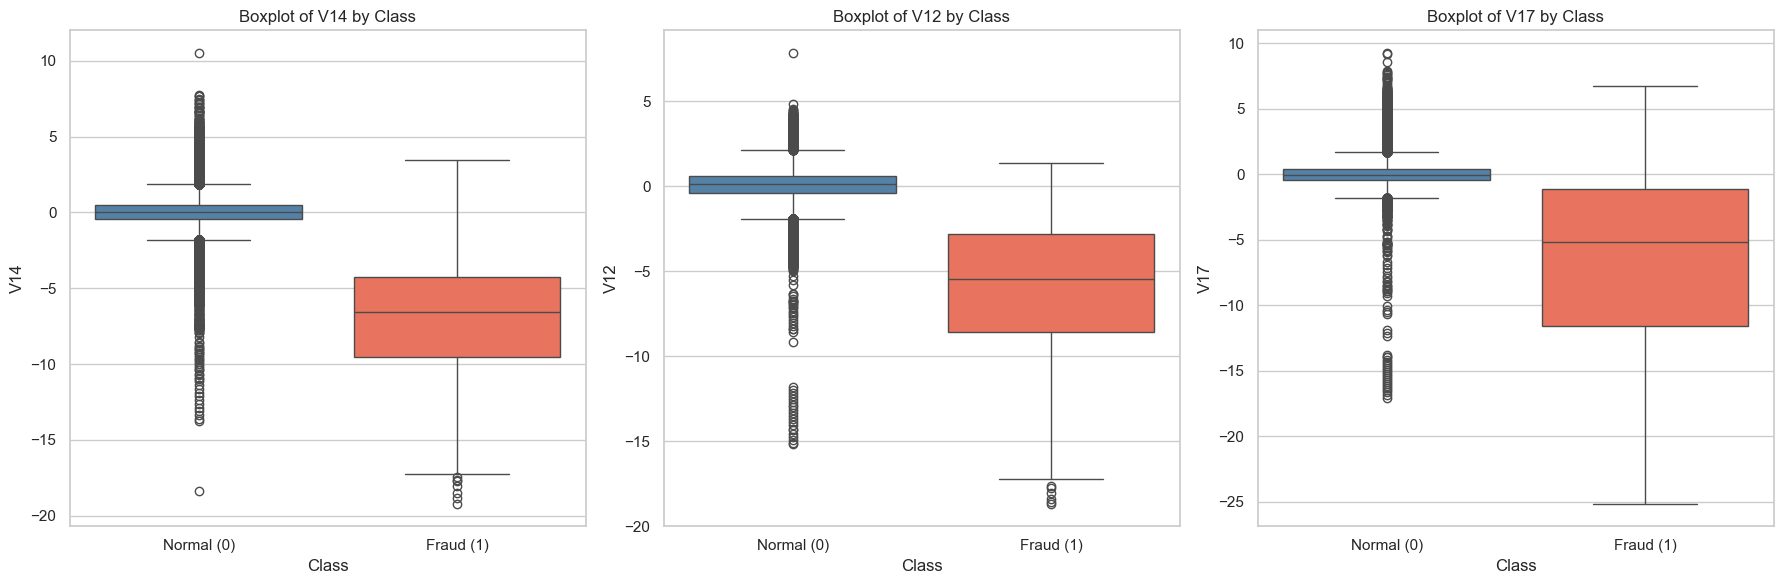

In [17]:
# ---------------------------------------------------------
# CELL 5: BOXPLOTS OF TOP PREDICTORS
# ---------------------------------------------------------
# Based on the bar chart, let's look at V14, V12, and V17.
# (If your bar chart shows different top features, change these!)
top_features = ['V14', 'V12', 'V17']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(top_features):
    sns.boxplot(x='Class', y=feature, data=df_full, 
                palette=['steelblue', 'tomato'], ax=axes[i])
    
    axes[i].set_title(f"Boxplot of {feature} by Class")
    axes[i].set_xticklabels(['Normal (0)', 'Fraud (1)'])

plt.tight_layout()
plt.show()

In [18]:
# ---------------------------------------------------------
# CELL 6: COMPARING AVERAGES (THE EYEBALL TEST)
# ---------------------------------------------------------
# Let's look at the top 5 most useful columns we found earlier
top_clues = ['V14', 'V12', 'V17', 'V4', 'V11']

print("Average value of clues for NORMAL transactions vs FRAUD:")
print("-" * 60)

# We group the data by 'Class' and calculate the mean for our chosen columns
averages = df_full.groupby('Class')[top_clues].mean().round(3)

# Rename the index so it's easy to read
averages.index = ['Normal (0)', 'Fraud (1)']
display(averages)

Average value of clues for NORMAL transactions vs FRAUD:
------------------------------------------------------------


,V14,V12,V17,V4,V11
Normal (0),0.012,0.009,0.011,-0.010,-0.006
Fraud (1),-6.836,-6.103,-6.463,4.473,3.716


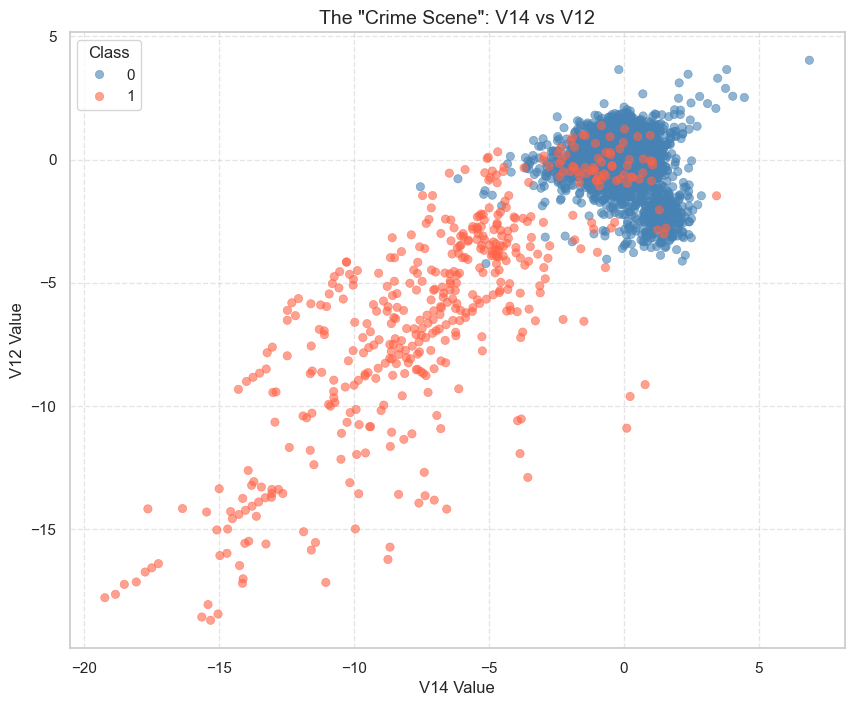

In [19]:
# ---------------------------------------------------------
# CELL 7: SCATTER PLOT OF THE BEST CLUES
# ---------------------------------------------------------
# 1. Grab all 492 Frauds
frauds = df_full[df_full['Class'] == 1]

# 2. Randomly grab 5000 Normal transactions so we don't crash matplotlib
normals = df_full[df_full['Class'] == 0].sample(n=5000, random_state=42)

# 3. Stick them together for the plot
plot_data = pd.concat([normals, frauds])

# 4. Draw the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='V14', y='V12', 
    hue='Class', 
    data=plot_data,
    palette={0: 'steelblue', 1: 'tomato'}, 
    alpha=0.6, # Makes the dots slightly transparent
    edgecolor=None
)

plt.title('The "Crime Scene": V14 vs V12', fontsize=14)
plt.xlabel('V14 Value')
plt.ylabel('V12 Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [22]:
# ---------------------------------------------------------
# CELL 9: STRATIFIED TRAIN/TEST SPLIT
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split

print("Preparing data for ML Baselines...")

# Separate the features (X) from the target variable (y)
# We use all variables for the generic baseline as requested!
X = df_full.drop(columns=['Class'])
y = df_full['Class']

# Perform the Stratified Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y,       # <-- THIS IS THE MAGIC WORD
    random_state=42   # Keeps the split consistent every time you run it
)

print(f"Training Set: {X_train.shape[0]:,} rows")
print(f" -> Normal: {sum(y_train == 0):,} | Fraud: {sum(y_train == 1)}")

print(f"\nTesting Set:  {X_test.shape[0]:,} rows")
print(f" -> Normal: {sum(y_test == 0):,} | Fraud: {sum(y_test == 1)}")

Preparing data for ML Baselines...
Training Set: 226,980 rows
 -> Normal: 226,602 | Fraud: 378

Testing Set:  56,746 rows
 -> Normal: 56,651 | Fraud: 95


Training Logistic Regression... (This takes a few seconds)


/Users/aryan/miniconda3/envs/math509/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest... (This might take 1-2 minutes)


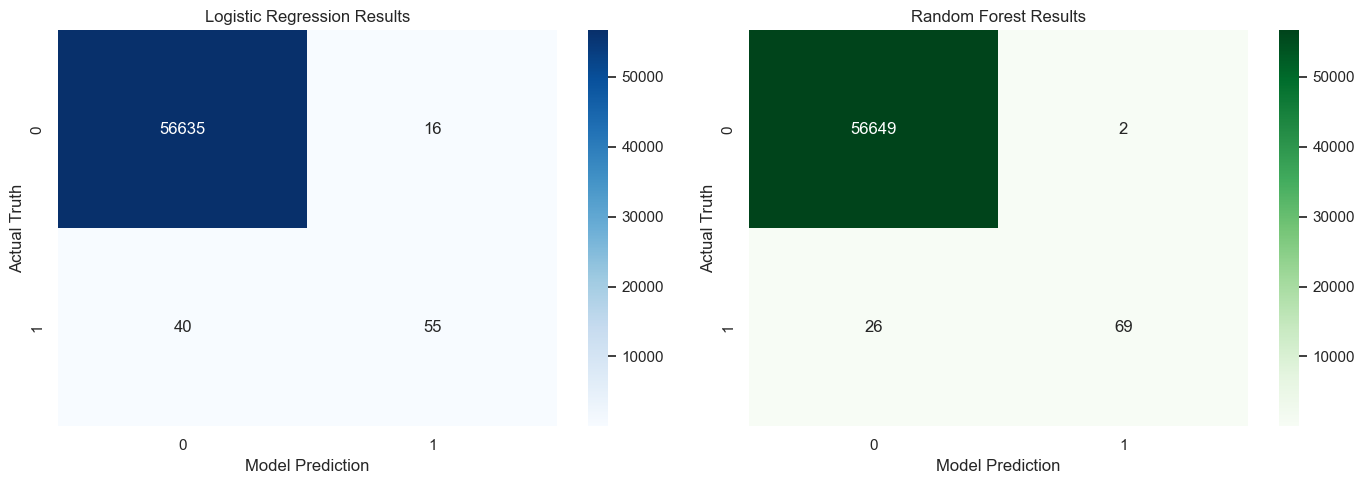


--- Random Forest Detailed Report ---
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56651
   Fraud (1)       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [23]:
# ---------------------------------------------------------
# CELL 10: TRAINING THE GENERIC BASELINES
# ---------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Training Logistic Regression... (This takes a few seconds)")
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print("Training Random Forest... (This might take 1-2 minutes)")
# n_jobs=-1 tells it to use all your Mac's CPU cores to go faster
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# --- Plotting the Results ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Results')
axes[0].set_ylabel('Actual Truth')
axes[0].set_xlabel('Model Prediction')

# Plot Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Results')
axes[1].set_ylabel('Actual Truth')
axes[1].set_xlabel('Model Prediction')

plt.tight_layout()
plt.show()

# Print the detailed breakdown for Random Forest (our usually "best" generic model)
print("\n--- Random Forest Detailed Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Normal (0)', 'Fraud (1)']))

In [24]:
from sklearn.preprocessing import StandardScaler

print("Selectively scaling only 'Time' and 'Amount'...")

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Fit the scaler ONLY on the training data, and transform the training data
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])

# 3. Transform the testing data using the rules learned from the training data
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("Scaling complete! V1-V28 were left untouched.")

Selectively scaling only 'Time' and 'Amount'...
Scaling complete! V1-V28 were left untouched.


In [25]:
# ---------------------------------------------------------
# CELL 11: CROSS-VALIDATION & PERFORMANCE TRANSLATION
# ---------------------------------------------------------
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
import numpy as np

print("Setting up 5-Fold Cross Validation...\n")

# 1. Define the CV strategy (Stratified keeps the 99.8% / 0.2% ratio in every fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define the model
cv_model = LogisticRegression(max_iter=1000)

# 3. Define the metrics we actually care about (Accuracy is banned!)
scoring_metrics = ['recall', 'precision', 'f1']

# 4. Run the Cross Validation
print("Running training and testing across 5 folds... (Please wait)")
cv_results = cross_validate(cv_model, X_train, y_train, 
                            cv=skf, scoring=scoring_metrics)

# 5. Extract the results
mean_recall = np.mean(cv_results['test_recall'])
std_recall = np.std(cv_results['test_recall'])

mean_precision = np.mean(cv_results['test_precision'])
std_precision = np.std(cv_results['test_precision'])

mean_f1 = np.mean(cv_results['test_f1'])
std_f1 = np.std(cv_results['test_f1'])

# ---------------------------------------------------------
# THE OUTPUT REPORT (Business + Data Science)
# ---------------------------------------------------------
print("\n" + "="*50)
print(" 📊 CROSS-VALIDATION RESULTS (5 Folds)")
print("="*50)

print("\n🏢 [BUSINESS TRANSLATION]")
print("-" * 30)
print(f"1. THE CATCH RATE (Recall): {mean_recall*100:.1f}%")
print(f"   -> Out of every 100 actual thieves, this model successfully caught ~{int(mean_recall*100)}.")
print(f"   -> It let ~{100 - int(mean_recall*100)} thieves walk away with the money.")

print(f"\n2. THE ANNOYANCE FACTOR (Precision): {mean_precision*100:.1f}%")
print(f"   -> When the model sounded the alarm and froze a customer's card, it was a real thief {int(mean_precision*100)}% of the time.")
print(f"   -> {100 - int(mean_precision*100)}% of the time, the bank accidentally froze an innocent person's card.")

print("\n🔬 [DATA SCIENCE METRICS (Mean ± Std Dev)]")
print("-" * 30)
print(f"Recall:    {mean_recall:.4f} ± {std_recall:.4f}")
print(f"Precision: {mean_precision:.4f} ± {std_precision:.4f}")
print(f"F1-Score:  {mean_f1:.4f} ± {std_f1:.4f}")
print("="*50)

Setting up 5-Fold Cross Validation...

Running training and testing across 5 folds... (Please wait)

 📊 CROSS-VALIDATION RESULTS (5 Folds)

🏢 [BUSINESS TRANSLATION]
------------------------------
1. THE CATCH RATE (Recall): 60.8%
   -> Out of every 100 actual thieves, this model successfully caught ~60.
   -> It let ~40 thieves walk away with the money.

2. THE ANNOYANCE FACTOR (Precision): 86.3%
   -> When the model sounded the alarm and froze a customer's card, it was a real thief 86% of the time.
   -> 14% of the time, the bank accidentally froze an innocent person's card.

🔬 [DATA SCIENCE METRICS (Mean ± Std Dev)]
------------------------------
Recall:    0.6084 ± 0.0459
Precision: 0.8635 ± 0.0211
F1-Score:  0.7121 ± 0.0253


Setting up RAM-Safe Heavy Artillery models... (Expected time: 4-6 mins)
Training Logistic Regression (Balanced)...
Training Linear SVM (Balanced)...
Training Random Forest (Balanced)...
Training Gradient Boosting (Hist)...

 🏆 FINAL GENERIC ML SHOWDOWN


,Model,Catch Rate (Recall %),Annoyance (Precision %),F1-Score
0,Logistic Regression (Balanced),91.80,5.95,0.11
1,Linear SVM (Balanced),90.74,7.36,0.14
2,Random Forest (Balanced),73.81,94.58,0.83
3,Gradient Boosting (Hist),53.44,46.87,0.50


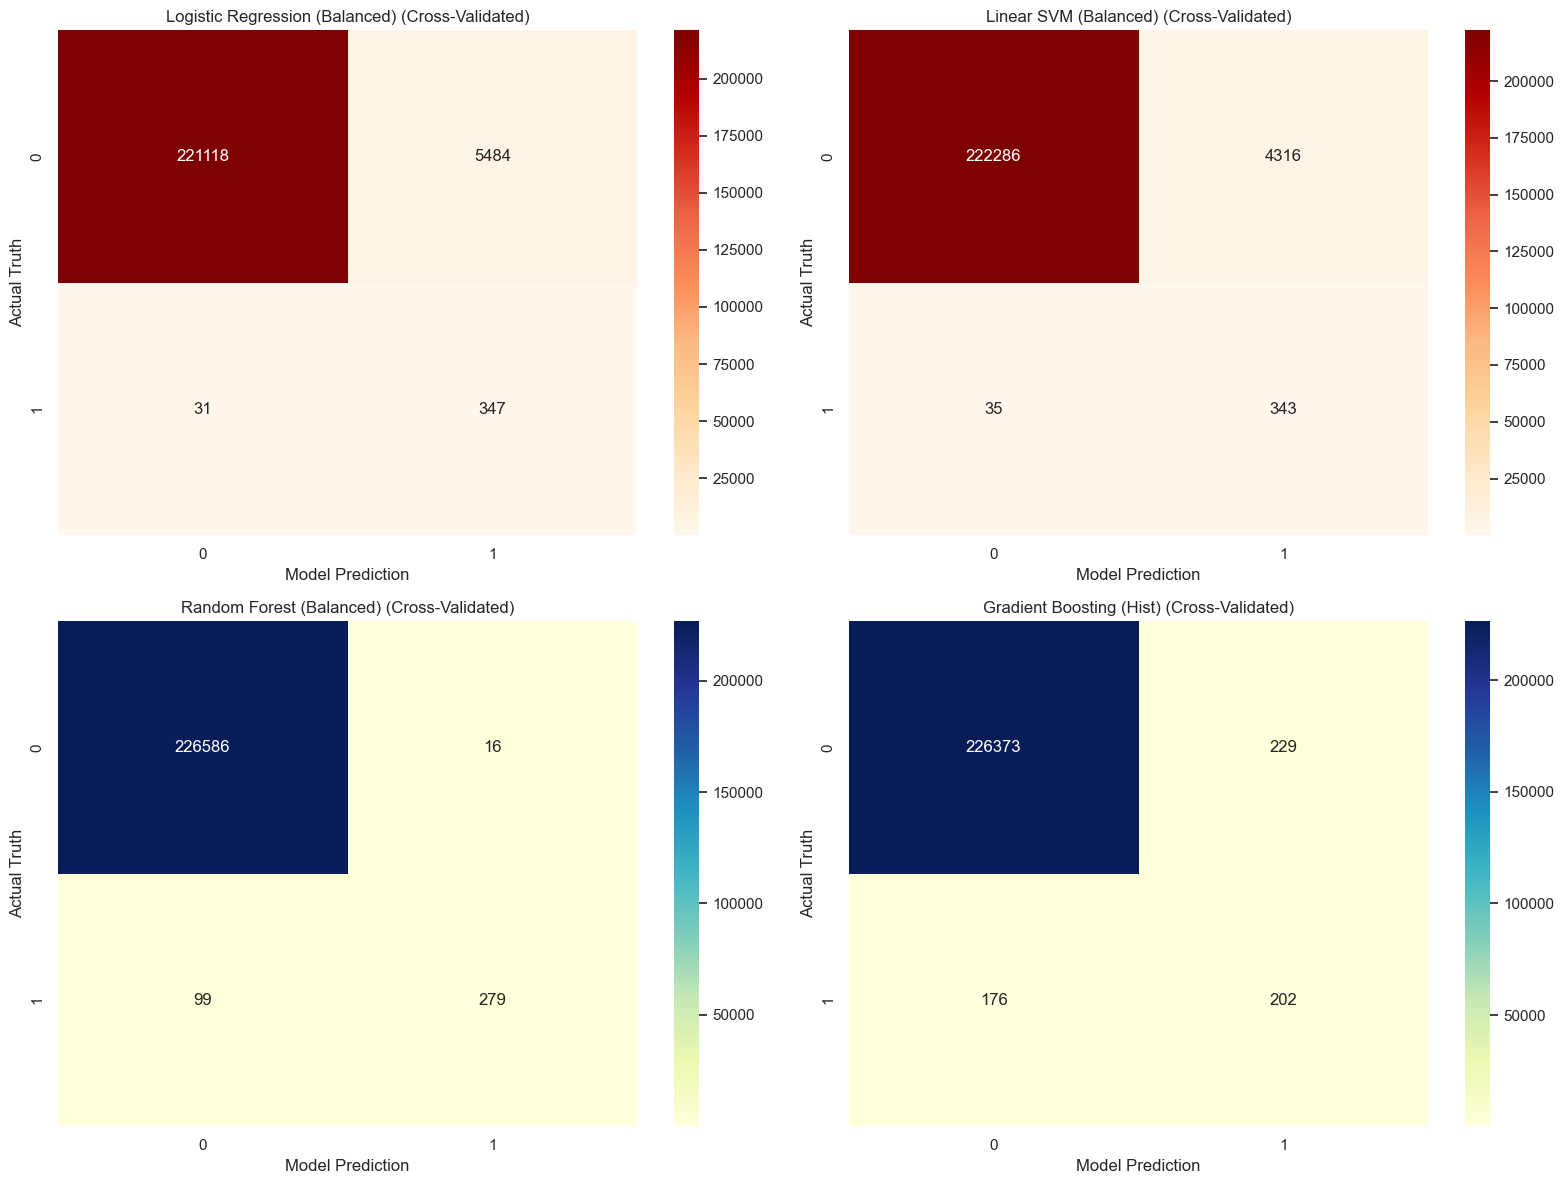


--- Visualizing the 'See-Saw' ---
Look at the top right square (False Positives / Innocent people blocked):
- Logistic/SVM will have HUGE numbers here (thousands of innocent people blocked).
Look at the bottom left square (False Negatives / Escaped Thieves):
- Random Forest/Boosting will have higher numbers here (Thieves getting away).


In [27]:
# ---------------------------------------------------------
# CELL 12: THE HEAVY ARTILLERY (WITH CONFUSION MATRICES)
# ---------------------------------------------------------
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Setting up RAM-Safe Heavy Artillery models... (Expected time: 4-6 mins)")

# 5 folds, preserving the exact 99.8% / 0.2% ratio
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define our arsenal (n_jobs=2 protects your 18GB of Unified Memory)
models = {
    "Logistic Regression (Balanced)": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Linear SVM (Balanced)": LinearSVC(class_weight='balanced', max_iter=2000, dual=False),
    "Random Forest (Balanced)": RandomForestClassifier(n_estimators=50, class_weight='balanced', n_jobs=2, random_state=42),
    "Gradient Boosting (Hist)": HistGradientBoostingClassifier(learning_rate=0.1, max_iter=100, random_state=42)
}

results_data = []
cms = {} # Dictionary to store confusion matrices

# 1. Train and Predict using cross_val_predict (saves 50% compute time!)
for name, model in models.items():
    print(f"Training {name}...")
    # This generates 'out-of-fold' predictions for the entire training set
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=skf, n_jobs=2)
    
    # Calculate metrics
    results_data.append({
        "Model": name,
        "Catch Rate (Recall %)": recall_score(y_train, y_pred_cv) * 100,
        "Annoyance (Precision %)": precision_score(y_train, y_pred_cv) * 100,
        "F1-Score": f1_score(y_train, y_pred_cv)
    })
    
    # Save the confusion matrix for plotting
    cms[name] = confusion_matrix(y_train, y_pred_cv)

# 2. Print the Business Results
print("\n" + "="*60)
print(" 🏆 FINAL GENERIC ML SHOWDOWN")
print("="*60)
results_df = pd.DataFrame(results_data).round(2)
display(results_df)

# 3. Plot all 4 Confusion Matrices Side-by-Side
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, cm) in enumerate(cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd' if 'SVM' in name or 'Logistic' in name else 'YlGnBu', ax=axes[i])
    axes[i].set_title(f'{name} (Cross-Validated)')
    axes[i].set_ylabel('Actual Truth')
    axes[i].set_xlabel('Model Prediction')

plt.tight_layout()
plt.show()

print("\n--- Visualizing the 'See-Saw' ---")
print("Look at the top right square (False Positives / Innocent people blocked):")
print("- Logistic/SVM will have HUGE numbers here (thousands of innocent people blocked).")
print("Look at the bottom left square (False Negatives / Escaped Thieves):")
print("- Random Forest/Boosting will have higher numbers here (Thieves getting away).")

🚨 INITIALIZING THE FINAL SHOWDOWN 🚨

1. Creating a 5% safe training subset for RBF and Poly SVMs...

2. Cross-Validating SVM Kernels on 5% Subset...
   -> Running CV for SVM: RBF Kernel...


/Users/aryan/miniconda3/envs/math509/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


      [CV Results] Catch Rate: 16.7% | Precision: 28.0%
   -> Running CV for SVM: Poly Kernel...
      [CV Results] Catch Rate: 73.3% | Precision: 56.7%

3. Testing all models on the UNSEEN 20% Test Set...

 🏆 FINAL TEST SET LEADERBOARD (UNSEEN DATA)


,Model,Catch Rate (Recall %),Annoyance (Precision %),F1-Score
0,Logistic Regression (Full Data),77.89,10.76,0.19
1,Random Forest (Full Data),72.63,97.18,0.83
2,SVM: RBF Kernel (5% Data),30.53,34.52,0.32
3,SVM: Poly Kernel (5% Data),62.11,36.65,0.46


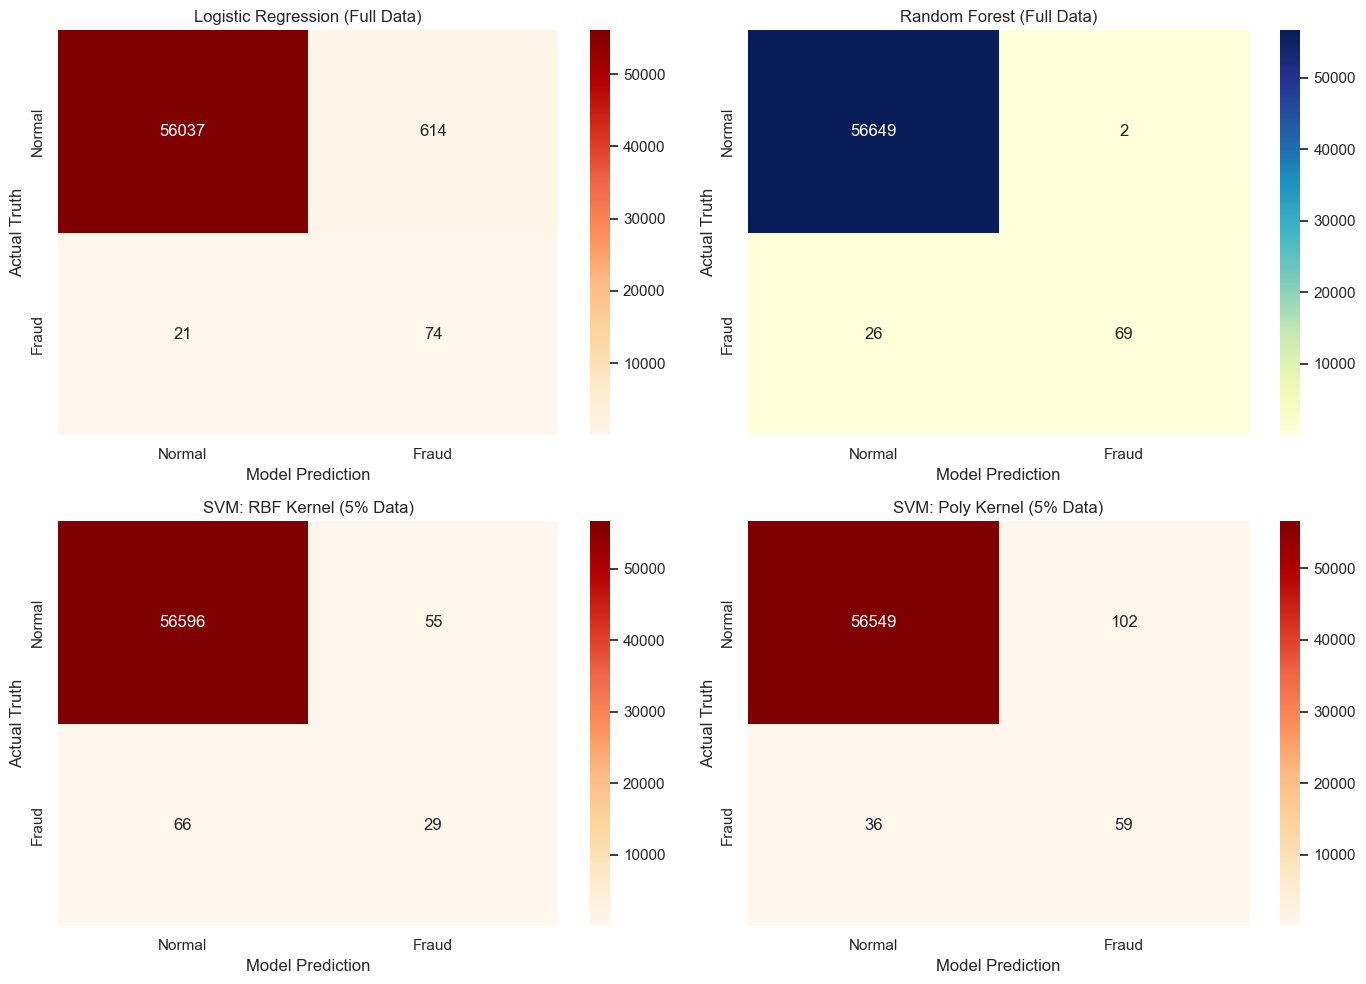

In [29]:
# ---------------------------------------------------------
# CELL 14: THE FINAL SHOWDOWN (SVM KERNELS & TEST SET)
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🚨 INITIALIZING THE FINAL SHOWDOWN 🚨\n")

# 1. Create a safe 5% subset for the heavy non-linear SVM kernels
print("1. Creating a 5% safe training subset for RBF and Poly SVMs...")
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train, train_size=0.05, stratify=y_train, random_state=42
)

# 2. Define the new non-linear SVM models
svm_models = {
    "SVM: RBF Kernel": SVC(kernel='rbf', class_weight='balanced', random_state=42),
    "SVM: Poly Kernel": SVC(kernel='poly', degree=2, class_weight='balanced', random_state=42)
}

# 3. Cross-Validate the new SVMs on the 5% subset
print("\n2. Cross-Validating SVM Kernels on 5% Subset...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['recall', 'precision', 'f1']

for name, model in svm_models.items():
    print(f"   -> Running CV for {name}...")
    cv_res = cross_validate(model, X_train_sub, y_train_sub, cv=skf, scoring=scoring_metrics)
    print(f"      [CV Results] Catch Rate: {np.mean(cv_res['test_recall'])*100:.1f}% | Precision: {np.mean(cv_res['test_precision'])*100:.1f}%")
    
    # Fit the model finally on the whole 5% subset for the Test Set evaluation
    model.fit(X_train_sub, y_train_sub)

# 4. Gather our trained models for the final Test Set run
# We grab log_reg and rf_model which are already in your Mac's memory from Cell 10!
print("\n3. Testing all models on the UNSEEN 20% Test Set...")
trained_models = {
    "Logistic Regression (Full Data)": log_reg,
    "Random Forest (Full Data)": rf_model,
    "SVM: RBF Kernel (5% Data)": svm_models["SVM: RBF Kernel"],
    "SVM: Poly Kernel (5% Data)": svm_models["SVM: Poly Kernel"]
}

results_data = []
cms = {}

for name, model in trained_models.items():
    # Predict directly on the Test Set
    y_pred_test = model.predict(X_test)
    
    results_data.append({
        "Model": name,
        "Catch Rate (Recall %)": recall_score(y_test, y_pred_test) * 100,
        "Annoyance (Precision %)": precision_score(y_test, y_pred_test) * 100,
        "F1-Score": f1_score(y_test, y_pred_test)
    })
    cms[name] = confusion_matrix(y_test, y_pred_test)

# 5. Print the Final Leaderboard
print("\n" + "="*70)
print(" 🏆 FINAL TEST SET LEADERBOARD (UNSEEN DATA)")
print("="*70)
results_df = pd.DataFrame(results_data).round(2)
display(results_df)

# 6. Plot the Confusion Matrices side-by-side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, cm) in enumerate(cms.items()):
    cmap = 'OrRd' if 'SVM' in name or 'Logistic' in name else 'YlGnBu'
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual Truth')
    axes[i].set_xlabel('Model Prediction')

plt.tight_layout()
plt.show()